
# Zero Downtime: Predictive Maintenance for NASA Turbofan Engines

### 1. The Business Problem: Why This Matters?
In the aviation industry, engine failure is not an option. Traditional maintenance is either **reactive** (fix it when it breaks - dangerous and costly) or **preventive** (replace parts on a schedule - wasteful if parts are still good).

The Gold Standard is **Predictive Maintenance (PdM)**. By analyzing sensor data, we can predict exactly *when* an engine will fail, allowing for maintenance at the perfect moment. This strategy:
- **Increases Safety:** Prevents catastrophic failures.
- **Reduces Costs:** Extends the life of expensive components.
- **Optimizes Operations:** Zero unplanned downtime.

**Goal:** Predict the **Remaining Useful Life (RUL)** of a turbofan engine based on sensor data using the NASA CMAPSS dataset.

---

### 2. The Dataset (NASA CMAPSS)
We are using the **FD001** subset of the NASA Turbofan Engine Degradation Simulation Data.
- **Input:** Multi-variate time-series data from 21 sensors (Temperature, Pressure, Fan Speeds, etc.).
- **Scenario:** Engines start normally and degrade over time until failure.
- **Target:** `RUL` (Remaining Useful Life) in cycles.

---

### 3. Methodology & Approach

### A. Data Cleaning & Feature Selection
Not all sensors carry information. Through EDA, I identified "Dead Sensors" that show constant values (Zero Variance).
- **Action:** Removed 7 sensors (e.g., `T2`, `P2`, `epr`, `farB`, etc.) to reduce noise and dimensionality.
- **Result:** A cleaner dataset focusing only on sensors that show degradation trends (like `T50` and `Ps30`).

###  B. Handling "Piecewise Linear" Degradation
Engines don't degrade linearly from Day 1. They stay healthy for a while, then degradation accelerates.
- **Technique:** I applied **RUL Clipping** (Threshold = 125 cycles).
- **Why?** This prevents the model from learning noise in the early stages of the engine's life and helps it focus on the critical degradation phase.

### C. Modeling Strategy
I benchmarked multiple algorithms to find the best balance between accuracy and speed:
1. **Linear Regression** (Baseline)
2. **SVR** (Support Vector Regressor)
3. **Random Forest**
4. **XGBoost Regressor** (Winner)

**XGBoost** outperformed others by capturing non-linear relationships between sensor readings and the aging process.

---

### 4. Final Results & Simulation
The final model was tested on unseen engines. Below is a simulation of the model predicting the lifecycle of a test engine in real-time.

* **Metric:** Root Mean Squared Error (RMSE)
* **Performance:** The model successfully tracks the degradation path, clearly identifying the "Failure Zone" (last 30 cycles).

---
*Created by: Mohamed AbdelAziz*


# Environment Setup & Data Ingestion

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/nasa-cmaps/CMaps/RUL_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/nasa-cmaps/CMaps/readme.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/x.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD001.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/RUL_FD002.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/test_FD003.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/nasa-cmaps/cmaps/CMaps/readme.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/train_FD003.txt
/kaggle/input/nasa-cmaps/cmaps/CM

In [2]:
# Define Column Names
index_names = ['unit_number', 'time_cycles']
operational_settings = ['setting_1', 'setting_2', 'setting_3']
# Grouping sensors helps in readability (Physical meanings)
sensor_names = [
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',        # Temperatures & Pressures
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',       # Rotational Speeds
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32' # Others
]
col_names = index_names + operational_settings + sensor_names
print(f"Column names defined. Total columns: {len(col_names)}")

Column names defined. Total columns: 26


In [3]:
base_path = "/kaggle/input/nasa-cmaps/CMaps"

fd001_train = pd.read_csv(f"{base_path}/train_FD001.txt", sep=r"\s+", header=None, names=col_names, engine="python")
fd001_test = pd.read_csv(f"{base_path}/test_FD001.txt", sep=r"\s+", header=None, names=col_names, engine="python")
rul = pd.read_csv(f"{base_path}/RUL_FD001.txt", sep=r"\s+", header=None, names=['RUL'], engine="python")

print("All datasets loaded successfully.")

All datasets loaded successfully.


# Data Inspection & Health Check
Before analyzing sensor behavior, we must validate our "Raw Materials". In this step, we perform a **Sanity Check** to ensure:
1.  **Data Volume:** Do we have enough samples for the model to learn?
2.  **Split Ratio:** Is the Train/Test split balanced?
3.  **Data Quality:** Are there any missing values (`Nulls`) that could crash the model?
4.  **Statistical Baseline:** What are the normal operating ranges for these sensors?

> **Note:** Detecting missing values or wrong data types here saves hours of debugging later.

In [ ]:
# Dimensionality Check
print(f'Training Data Shape: {fd001_train.shape}')
print(f'Testing Data Shape:  {fd001_test.shape}')
print(f'RUL File Shape:      {rul.shape}')
# Check the ratio of testing data
print(f"Percentage of Testing Data: {len(fd001_test)/(len(fd001_train)+len(fd001_test)):.2%}")

: 

In [5]:
# "Trust but Verify": Looking at the raw data to spot any obvious formatting issues by Visual Inspection.
print('-' * 30 + '\nDataset Preview (First 5 Rows) -> Training Data :\n')
display(fd001_train.head())
print('-' * 30 + '\nDataset Preview (Last 5 Rows) -> Training Data :\n')
display(fd001_train.tail())

------------------------------
Dataset Preview (First 5 Rows) -> Training Data :



,unit_number,time_cycles,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


------------------------------
Dataset Preview (Last 5 Rows) -> Training Data :



,unit_number,time_cycles,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,519.30,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522


In [6]:
# Data Integrity Audit (Nan values)
print("Missing Values in Train:", fd001_train.isnull().sum().sum())
print("Missing Values in Test:", fd001_test.isnull().sum().sum())

Missing Values in Train: 0
Missing Values in Test: 0


In [7]:
# Data Type & Memory Check
fd001_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   T2           20631 non-null  float64
 6   T24          20631 non-null  float64
 7   T30          20631 non-null  float64
 8   T50          20631 non-null  float64
 9   P2           20631 non-null  float64
 10  P15          20631 non-null  float64
 11  P30          20631 non-null  float64
 12  Nf           20631 non-null  float64
 13  Nc           20631 non-null  float64
 14  epr          20631 non-null  float64
 15  Ps30         20631 non-null  float64
 16  phi          20631 non-null  float64
 17  NRf          20631 non-null  float64
 18  NRc          20631 non-null  float64
 19  BPR 

In [8]:
# Statistical Summary
fd001_train.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
time_cycles,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
T2,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
T24,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
T30,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
T50,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
P2,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200


# Cleaning & Feature Engineering

#### **A. The Challenge of "Constant" Sensors**
One of the first steps is removing sensors that provide no information (Constant Values).
* **Hypothesis:** A sensor with `std = 0` is constant.
* **Reality Check:** In real-world sensor data, floating-point precision issues (Machine Epsilon) can cause a constant sensor to have a tiny standard deviation (e.g., $10^{-15}$) instead of a perfect $0.0$.

> **Technical Insight:** Relying solely on `std() == 0` failed to detect all constant sensors (like `P2` and `farB`).
> **Solution:** We switched to counting unique values (`nunique()`). If a sensor has only **1 unique value**, it is guaranteed to be constant, regardless of numerical noise.

#### **B. Target Engineering (RUL)**
We calculate the **Remaining Useful Life (RUL)** and apply a cap (Clipping) at **125 cycles** to model the healthy phase of the engine accurately.

In [9]:
# Handling Constant (Dead) Sensors
# Objective: Remove features that carry no information (Variance = Information)

"""
 METHOD 1: Variance Thresholding
 Initially, I tried to remove sensors where standard deviation == 0.
 BUT, due to floating-point precision, some effectively constant sensors
 showed a tiny std (e.g., 0.000000001), causing this method to fail.

 stats = fd001_train.describe().T
 constant_features_v1 = stats[stats['std'] == 0].index.tolist()
 print(f"Method 1 detected {len(constant_features_v1)} sensors (Missed 'P2', 'farB')")
"""

"""
 METHOD 2: Unique Value Counting
 Instead, we check the number of unique values.
 If unique count <= 1, the sensor is absolutely constant.
"""
constant_features = [col for col in fd001_train.columns if fd001_train[col].nunique() <= 1]

print(f'Dead/Constant Sensors identified: {constant_features}')
print(f'Number of Dead Sensors: {len(constant_features)} sensors.')

Dead/Constant Sensors identified: ['setting_3', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
Number of Dead Sensors: 7 sensors.


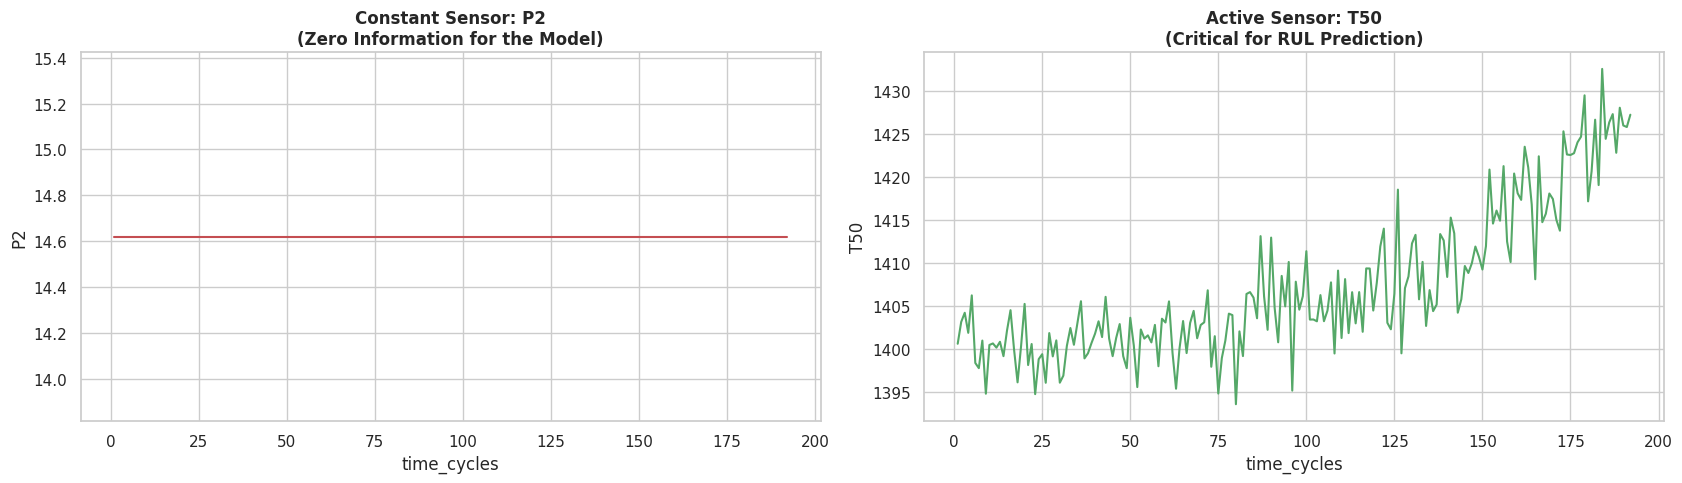

In [10]:
# Visual Validation (Proving the Point)
# Let's plot 'P2' (which Method 1 missed) vs 'T50' (Active)

dead_sensor = 'P2'
active_sensor = 'T50'

fig, ax = plt.subplots(1, 2, figsize=(17, 5))

# Plot Dead Sensor
sns.lineplot(x='time_cycles', y=dead_sensor,
             data=fd001_train[fd001_train['unit_number'] == 1],
             ax=ax[0], color='r')
ax[0].set_title(
    f'Constant Sensor: {dead_sensor}\n(Zero Information for the Model)',
    fontweight='bold')

# Plot Active Sensor
sns.lineplot(x='time_cycles', y=active_sensor,
             data=fd001_train[fd001_train['unit_number'] == 1],
             ax=ax[1], color='g')
ax[1].set_title( f'Active Sensor: {active_sensor}\n(Critical for RUL Prediction)',
                 fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
# drop these sensors (Dead Sensors) from training and test data
fd001_train.drop(columns=constant_features, inplace=True)
fd001_test.drop(columns=constant_features, inplace=True)

print("\nDropped constant columns successfully.")
print(f"New Training Shape: {fd001_train.shape}")


Dropped constant columns successfully.
New Training Shape: (20631, 19)


Constructing the Target (RUL)** The dataset provides the total life, but we need to predict the **Remaining Useful Life (RUL)** at any given point.
 * **Formula:** $RUL(t) = T_{max} - t$

In [12]:
# RUL Calculation
def calculate_rul(data, unit_col='unit_number', cycle_col='time_cycles'):
    max_cycle = (
        data.groupby(unit_col)[cycle_col].max()
        .reset_index().rename(columns={cycle_col: 'max_of_unit'}))
    data = data.merge(max_cycle, on=unit_col, how='left')
    data['RUL'] = data['max_of_unit'] - data[cycle_col]
    data.drop('max_of_unit', axis=1, inplace=True)
    return data


fd001_train = calculate_rul(fd001_train)
fd001_train[['unit_number', 'time_cycles', 'RUL']].head()

,unit_number,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


Piecewise Linear RUL (Clipping)** Engines don't degrade linearly from Day 1. They operate normally (Healthy State) for a while, then degradation accelerates. * **Technique:** We clip the RUL at **125 cycles**.
 * **Why?** This prevents the model from trying to predict "infinite health" in the early stages, focusing its attention on the critical degradation phase

In [13]:
# RUL Clipping
RUL_THRESHOLD = 125
fd001_train['RUL'] = fd001_train['RUL'].clip(upper=RUL_THRESHOLD)
print(f"RUL Clipping applied. Max RUL is now capped at {RUL_THRESHOLD} cycles.")
print("\nRUL Statistics after Clipping:")

fd001_train['RUL'].describe().T

RUL Clipping applied. Max RUL is now capped at 125 cycles.

RUL Statistics after Clipping:


count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

# Exploratory Data Analysis (EDA)

#### **A. Survival Analysis: How long do engines last?**
Before building predictive models, we need to establish a **baseline**.
* **Objective:** Understand the distribution of "Time-to-Failure".
* **Why?** If most engines fail around 200 cycles, a model predicting 500 cycles is obviously wrong.

In [14]:
# Lifespan Statistics
engine_lifespan = fd001_train.groupby('unit_number')['time_cycles'].max()

print("Mean Lifespan:", engine_lifespan.mean())
print("Min Lifespan:", engine_lifespan.min())
print("Max Lifespan:", engine_lifespan.max())

Mean Lifespan: 206.31
Min Lifespan: 128
Max Lifespan: 362


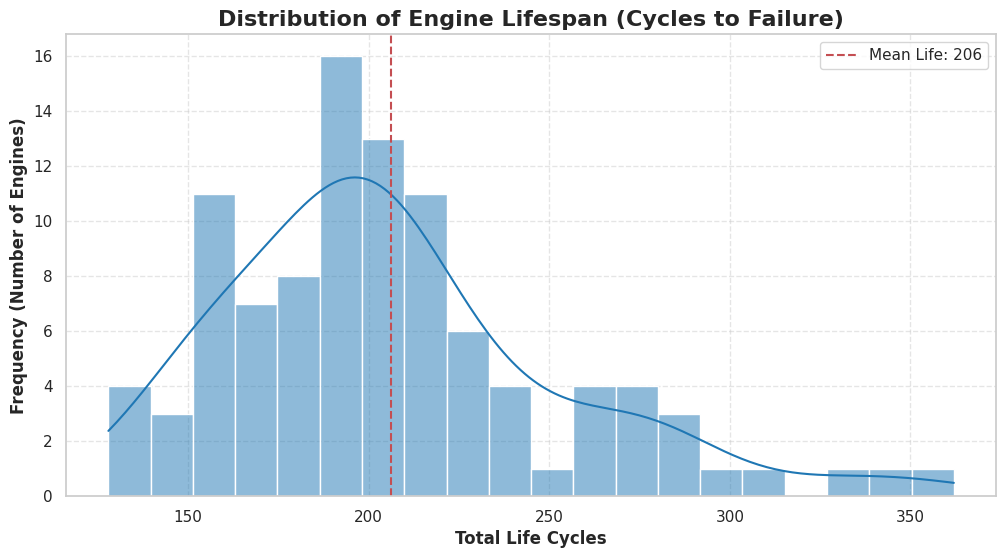

In [15]:
# Lifespan Distribution

# Histogram (Distribution)
plt.figure(figsize=(12, 6))
sns.histplot(engine_lifespan, kde=True, color='#1f77b4', bins=20)
plt.title('Distribution of Engine Lifespan (Cycles to Failure)', fontweight='bold', size=16)
plt.xlabel('Total Life Cycles', fontweight='bold', size=12)
plt.ylabel('Frequency (Number of Engines)', fontweight='bold', size=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axvline(engine_lifespan.mean(), color='r', linestyle='--', label=f'Mean Life: {int(engine_lifespan.mean())}')
plt.legend()
plt.show()

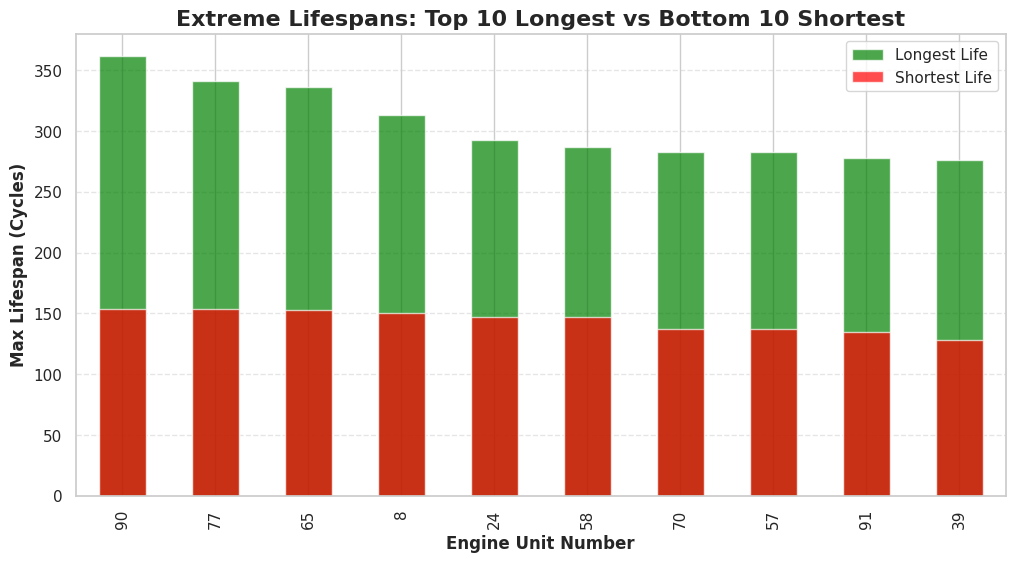

In [16]:
# Bar Chart (Extremes)
sorted_lifespan = engine_lifespan.sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sorted_lifespan.head(10).plot(kind='bar', color='green', alpha=0.7, label='Longest Life')
sorted_lifespan.tail(10).plot(kind='bar', color='red', alpha=0.7, label='Shortest Life')
plt.title('Extreme Lifespans: Top 10 Longest vs Bottom 10 Shortest', fontweight='bold', size=16)
plt.xlabel('Engine Unit Number', fontweight='bold')
plt.ylabel('Max Lifespan (Cycles)', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend()
plt.show()

#### B. Sensor Degradation Analysis
Now we dig deeper into the physics of failure.
1.  **Correlation:** Which sensors drift as RUL decreases?
2.  **Signal Trajectory:** Visualizing the smoothed degradation path.
3.  **Separability:** Can we easily distinguish "Healthy" vs "Failing" states?
4.  **PCA Projection:** Compressing 14+ sensors into a 2D map to see the "Path to Failure".

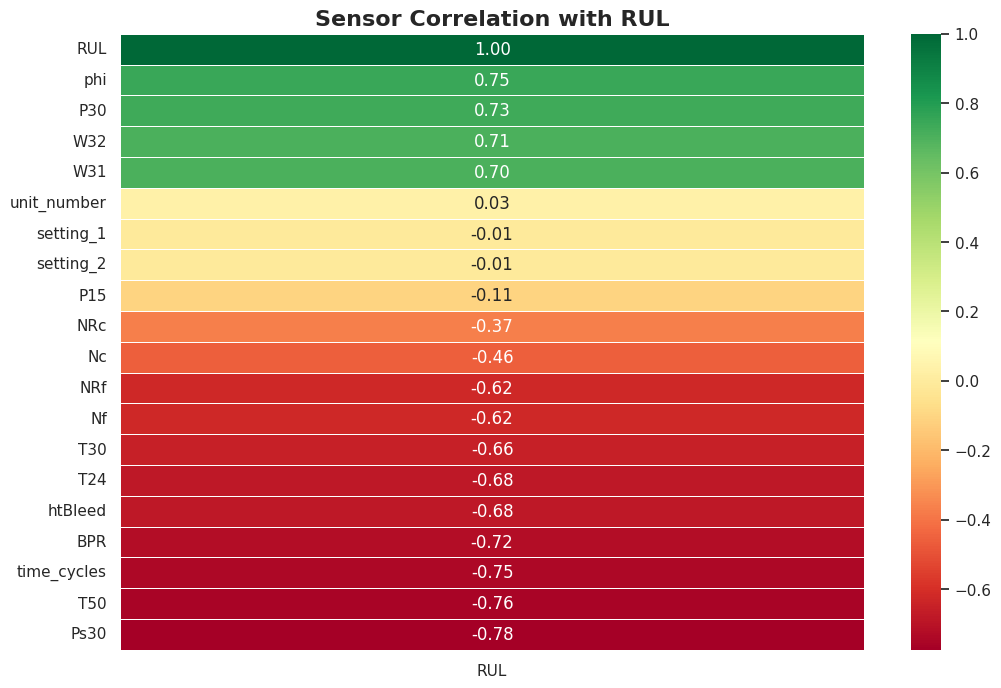

Insight: Sensors with high positive or negative correlation are the most important predictors.


In [17]:
# Correlation Heatmap

# Which sensors correlate most strongly with RUL?
corr_matrix = fd001_train.corr()
rul_corr = corr_matrix['RUL'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(12, 8))
sns.heatmap(rul_corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Sensor Correlation with RUL', fontsize=16, fontweight='bold')
plt.show()

print("Insight: Sensors with high positive or negative correlation are the most important predictors.")

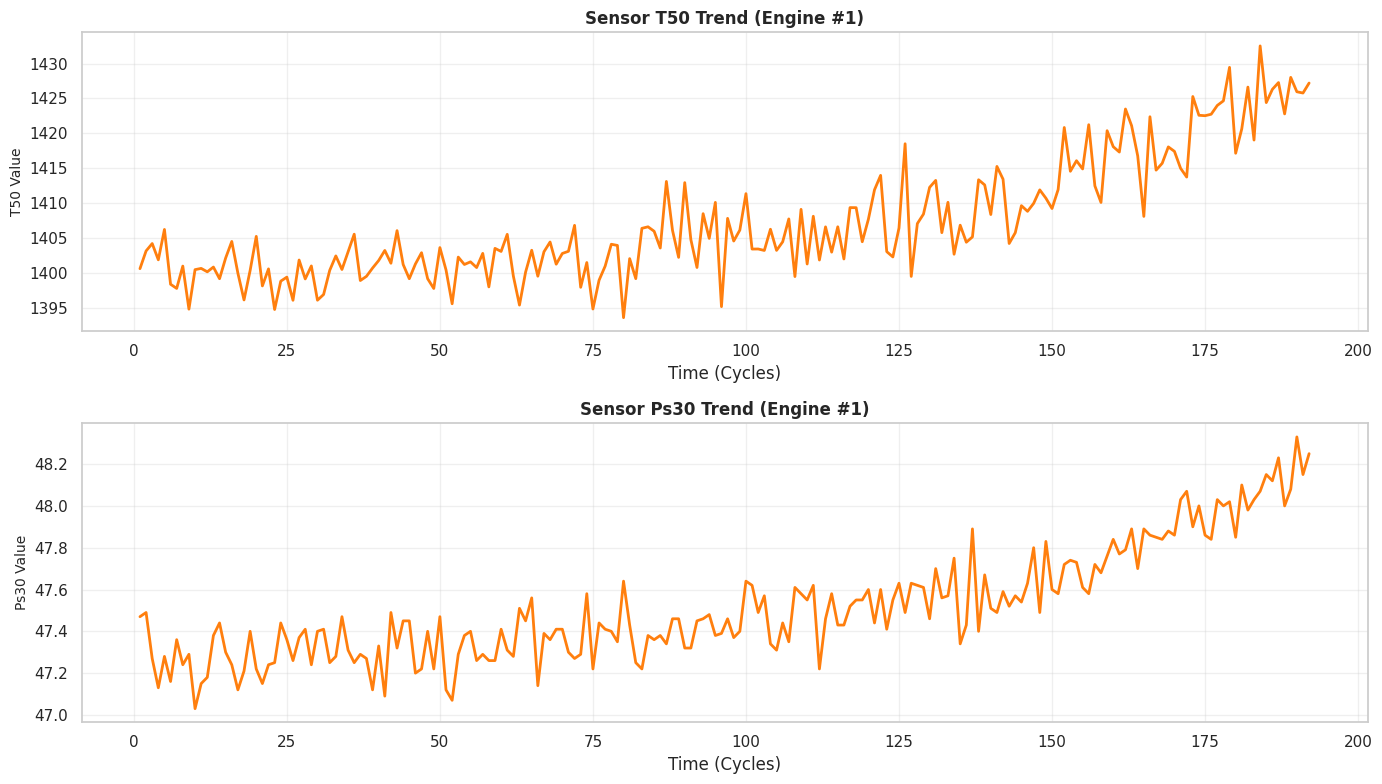

In [18]:
# Visualize key sensors identified by correlation

top_sensors = ['T50', 'Ps30']
sample_unit = 1

fig, ax = plt.subplots(len(top_sensors), 1, figsize=(14, 8))

for i, sensor in enumerate(top_sensors):
    unit_data = fd001_train[fd001_train['unit_number'] == sample_unit]
    ax[i].plot(unit_data['time_cycles'], unit_data[sensor], color='#ff7f0e', linewidth=2)
    ax[i].set_title(f'Sensor {sensor} Trend (Engine #{sample_unit})', fontsize=12, fontweight='bold')
    ax[i].set_ylabel(f'{sensor} Value', fontsize=10)
    ax[i].set_xlabel('Time (Cycles)')
    ax[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

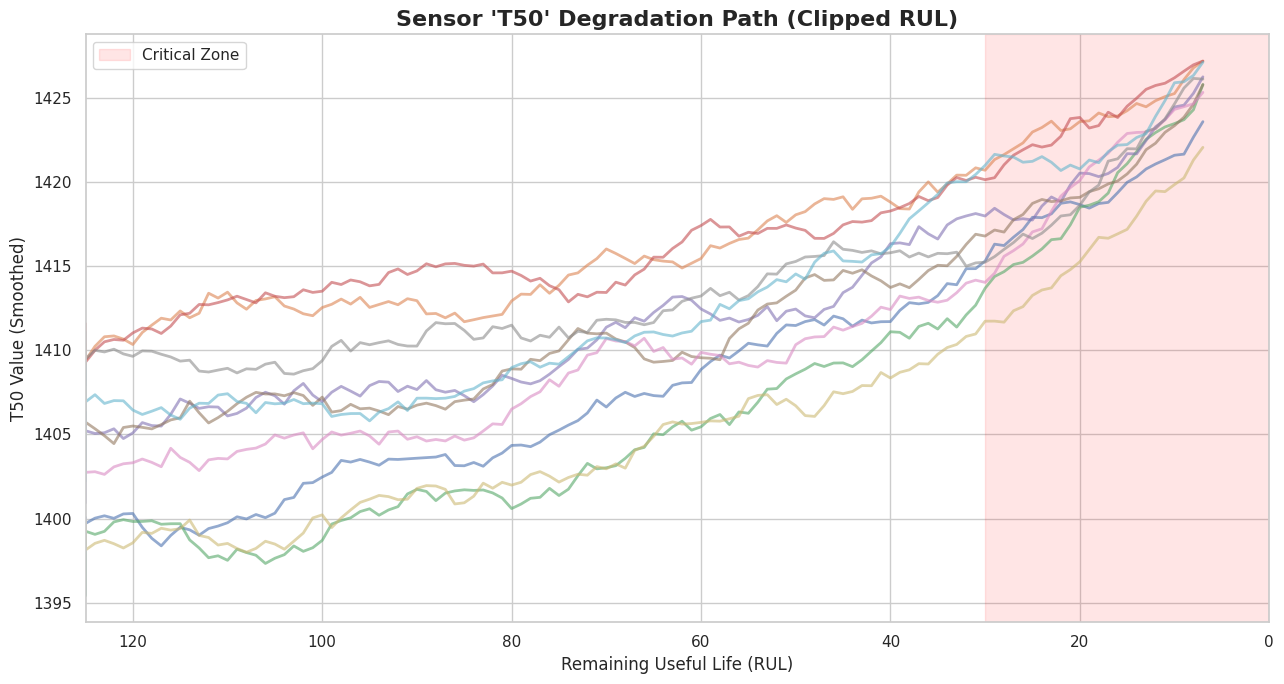

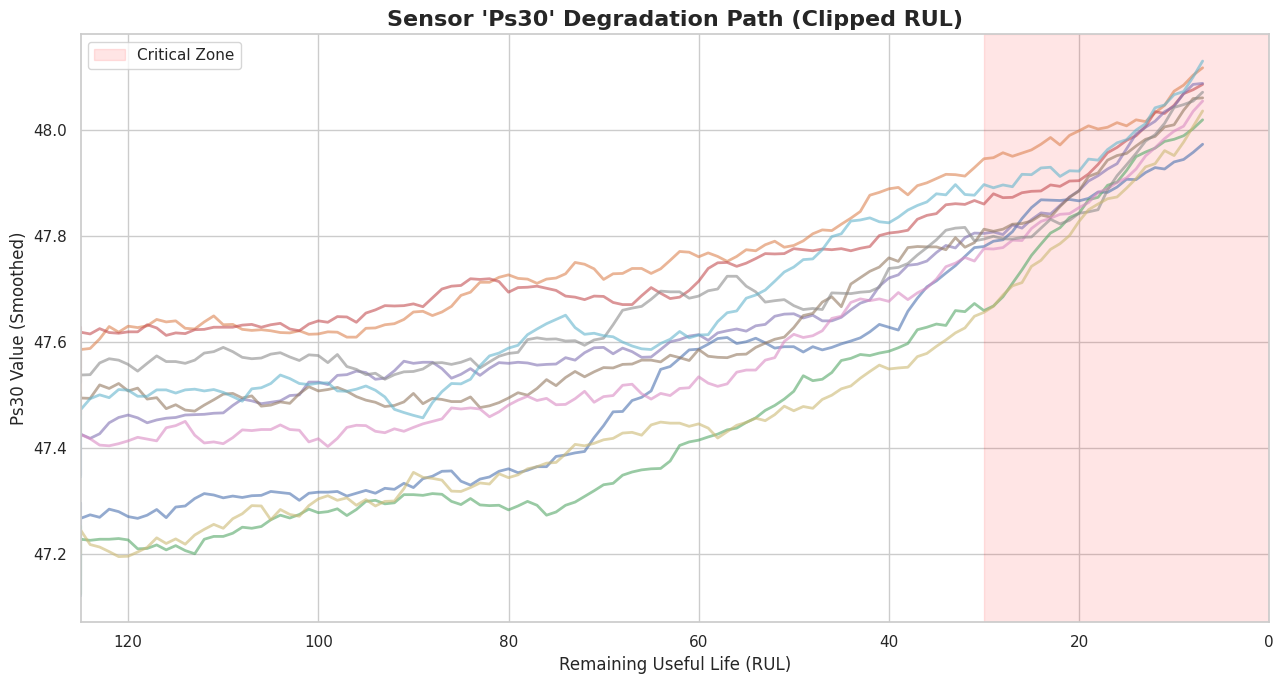

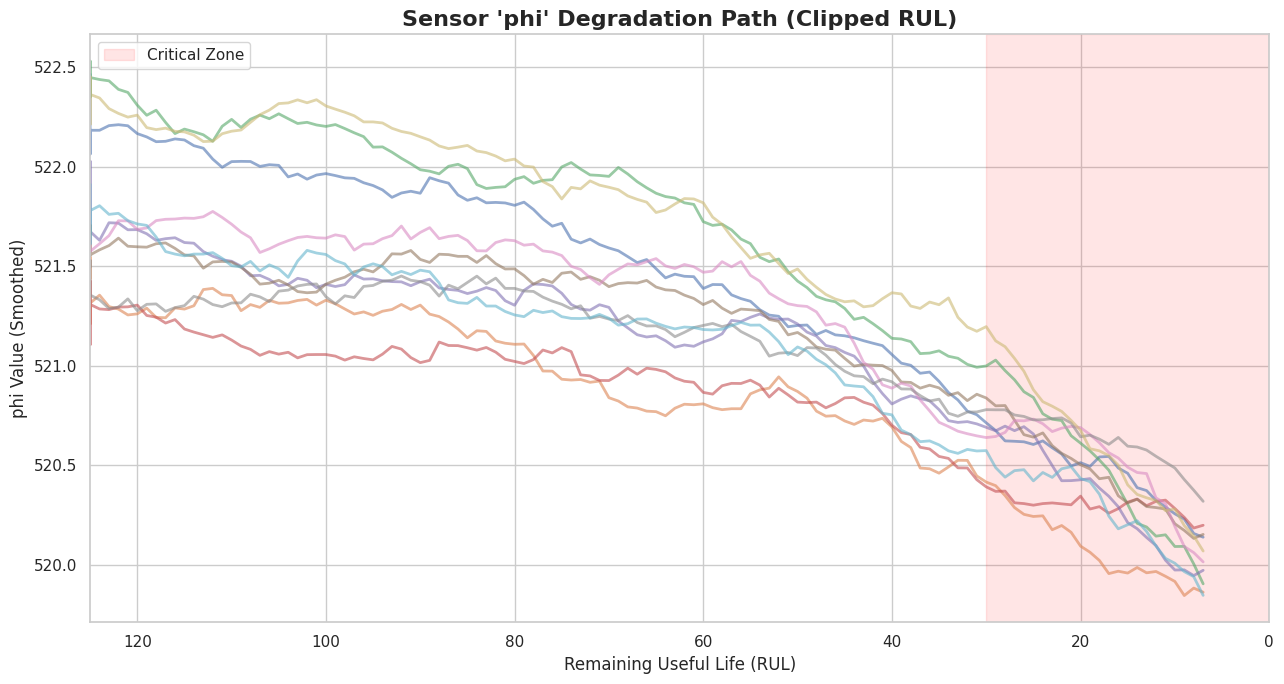

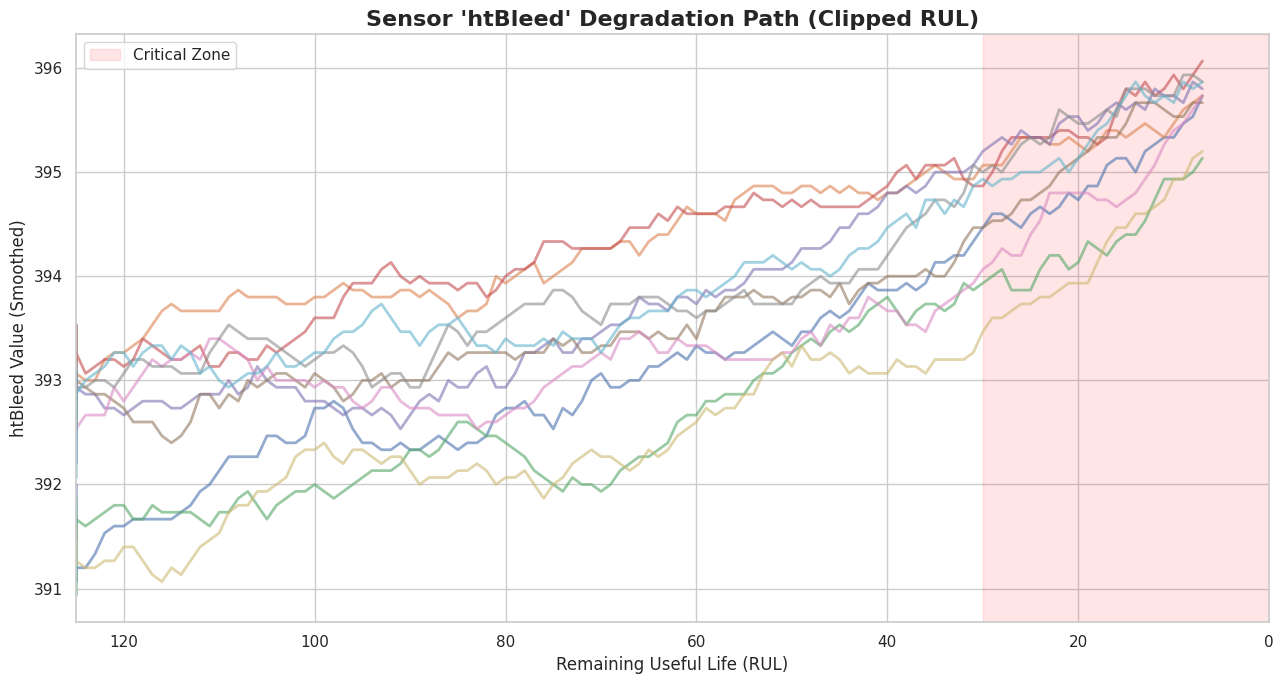

In [19]:
# Degradation Trends (Smoothed)

"""
Plots the smoothed trend of a sensor over the RUL.
Visualizes how the sensor reading changes as the engine approaches failure.
"""


def plot_engine_evolution_v2(df, sensor_name):
    if sensor_name not in df.columns:
        return
    plt.figure(figsize=(13, 7))
    # Plot a sample of units (every 10th unit) to avoid clutter
    units_to_plot = [u for u in df['unit_number'].unique() if u % 10 == 0]
    for unit in units_to_plot:
        unit_data = df[df['unit_number'] == unit]
        # Smoothing (Rolling Mean) to visualize the trend better
        smoothed_signal = unit_data[sensor_name].rolling(window=15, center=True).mean()
        plt.plot(unit_data['RUL'], smoothed_signal, linewidth=2, alpha=0.6, label=f'Unit {unit}')

    plt.xlim(max(df['RUL']), 0) # Reverse X-axis (High RUL -> 0 RUL)
    plt.axvspan(30, 0, color='red', alpha=0.1, label='Critical Zone (<30 Cycles)')
    plt.title(f"Sensor '{sensor_name}' Degradation Path (Clipped RUL)", fontsize=16, fontweight='bold')
    plt.xlabel('Remaining Useful Life (RUL)', fontsize=12)
    plt.ylabel(f'{sensor_name} Value (Smoothed)', fontsize=12)

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    if 'Critical Zone (<30 Cycles)' in by_label:
        plt.legend([by_label['Critical Zone (<30 Cycles)']], ['Critical Zone'], loc='upper left')
    plt.tight_layout()
    plt.show()


desired_sensors = ['T50', 'Ps30', 'phi', 'htBleed']
valid_sensors_to_plot = [s for s in desired_sensors if s in fd001_train.columns]

for sensor in valid_sensors_to_plot:
    plot_engine_evolution_v2(fd001_train, sensor)

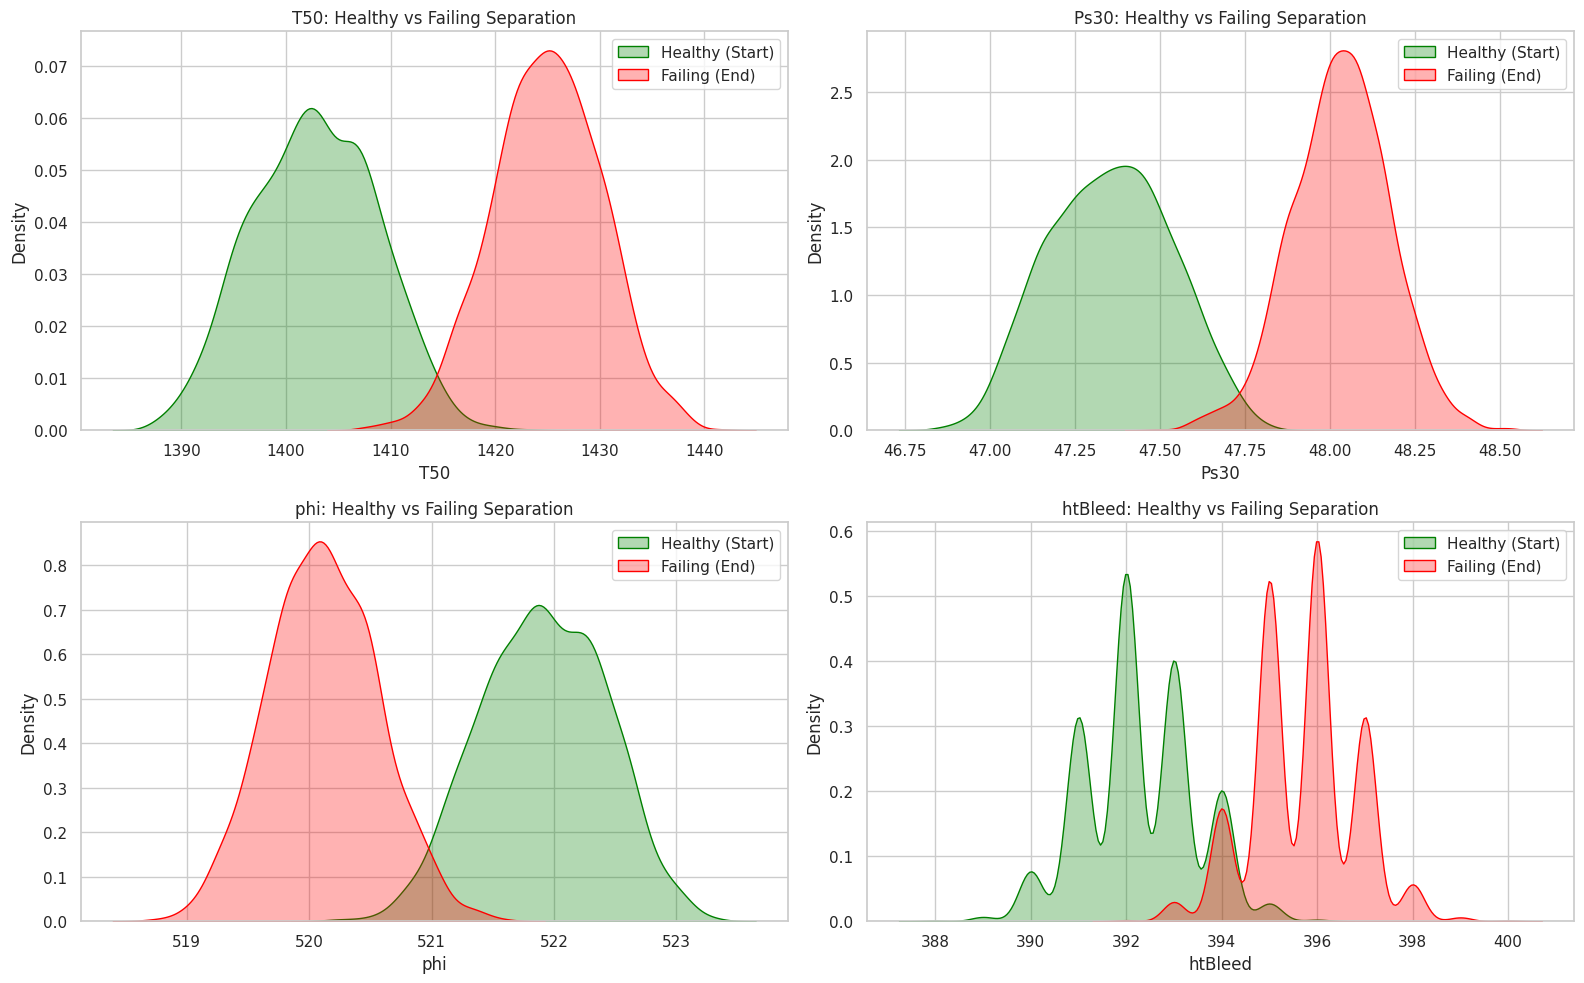

In [20]:
# Health State Separation (KDE Plot)
# Can we distinguish between a 'New' engine and a 'Dying' engine?

early_life = fd001_train[fd001_train['time_cycles'] < 20]# First 20 cycles
late_life = fd001_train[fd001_train['RUL'] < 20]# Last 20 cycles

sensors_to_compare = ['T50', 'Ps30', 'phi', 'htBleed']
available_sensors = [s for s in sensors_to_compare if s in fd001_train.columns]

if available_sensors:
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
    axes = axes.flatten()

    for i, sensor in enumerate(available_sensors):
        sns.kdeplot(early_life[sensor], fill=True, color="green", label='Healthy (Start)', ax=axes[i], alpha=0.3)
        sns.kdeplot(late_life[sensor], fill=True, color="red", label='Failing (End)', ax=axes[i], alpha=0.3)
        axes[i].set_title(f'{sensor}: Healthy vs Failing Separation')
        axes[i].legend()
    plt.tight_layout()
    plt.show()
else:
    print("Warning: Selected sensors were dropped during cleaning.")

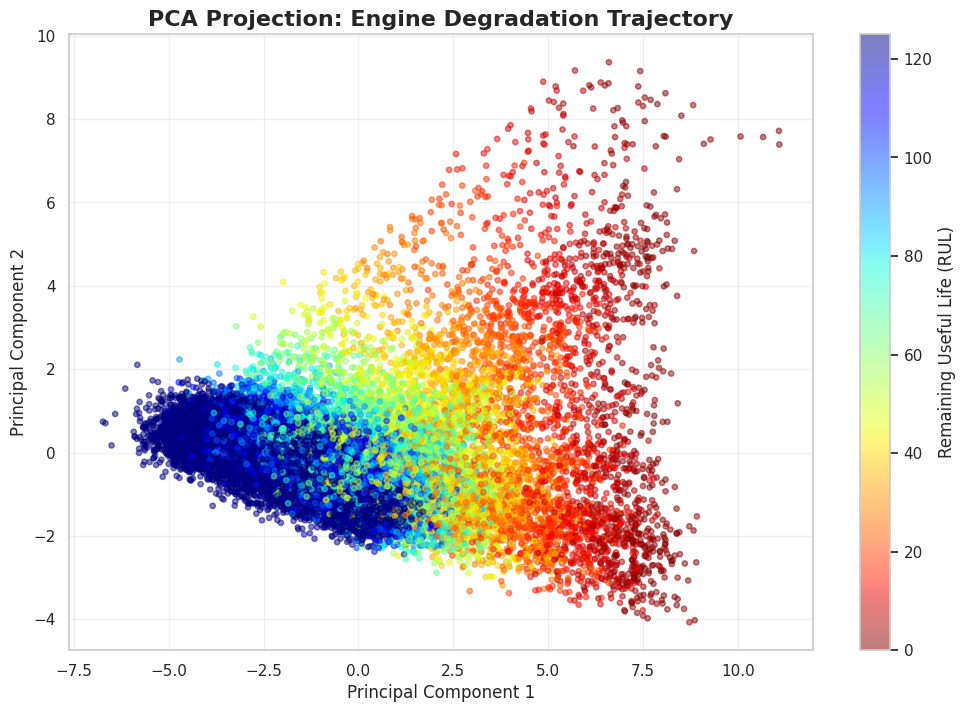

Explained Variance Ratio: 65.44%
Meaning: These 2 components hold 65% of the sensors' information.


In [21]:
# PCA Projection (2D Manifold)
# Compressing all sensor data into 2 dimensions to visualize the "Trajectory of Death"

features_for_pca = [col for col in fd001_train.columns if col not in ['unit_number', 'time_cycles', 'RUL']]

x_pca = StandardScaler().fit_transform(fd001_train[features_for_pca])

pca = PCA(n_components=2)
principal_components = pca.fit_transform(x_pca)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['RUL'] = fd001_train['RUL']

plt.figure(figsize=(12, 8))
sc = plt.scatter( pca_df['PC1'], pca_df['PC2'], c=pca_df['RUL'],
    cmap='jet_r', alpha=0.5, s=15)

plt.colorbar(sc, label='Remaining Useful Life (RUL)')
plt.title('PCA Projection: Engine Degradation Trajectory', fontsize=16, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_.sum():.2%}")
print("Meaning: These 2 components hold {:.0f}% of the sensors' information.".format(pca.explained_variance_ratio_.sum()*100))

# Preprocessing & Modeling

Machine Learning models (like Linear Regression, SVR, and Neural Networks) are sensitive to the scale of input features.
* **The Problem:** Sensor `T50` might range from 1000-2000, while `Ps30` ranges from 10-20. The model might biasedly think `T50` is more important just because the numbers are bigger.
* **The Solution:** We apply **MinMax Scaling** to bring all features into the range $[0, 1]$.
* **Critical Rule:** We `fit` the scaler ONLY on the **Training Data** to prevent Data Leakage, then we apply that same scaler to the Test Data.

In [22]:
# Select features to scale
## We exclude 'unit_number', 'time_cycles', and 'RUL' because they are identifiers/targets, not sensor inputs.

features_to_normalize = [col for col in fd001_train.columns if col not in ['unit_number', 'time_cycles', 'RUL']]
scaler = MinMaxScaler()
fd001_train[features_to_normalize] = scaler.fit_transform(fd001_train[features_to_normalize])
fd001_test[features_to_normalize] = scaler.transform(fd001_test[features_to_normalize])


print("\nScaling completed successfully.")
print(f"Features Scaled: {len(features_to_normalize)}")

print("Data Scaling Completed (Range 0-1).")
print('-' * 30 + '\nData Preview after Scaling (Train) :\n')
display(fd001_train.head())

print('-' * 30 + '\nCheck Min/Max values (Should be 0 and 1) :\n')
display(fd001_train[features_to_normalize].describe().loc[['min', 'max']])


Scaling completed successfully.
Features Scaled: 17
Data Scaling Completed (Range 0-1).
------------------------------
Data Preview after Scaling (Train) :



,unit_number,time_cycles,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
0,1,1,0.459770,0.166667,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,125
1,1,2,0.609195,0.250000,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,125
2,1,3,0.252874,0.750000,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,125
3,1,4,0.540230,0.500000,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,125
4,1,5,0.390805,0.333333,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,125


------------------------------
Check Min/Max values (Should be 0 and 1) :



,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Splitting Data for Evaluation

In the C-MAPSS dataset challenge, the evaluation criteria is specific:
* **Training:** We use the full history of the training units.
* **Testing:** We are given partial history for test units, and we must predict the RUL at the **very last recorded cycle**.

Therefore, for the Test Set (`X_test`), we extract only the **last row** of data for each engine unit to compare it against the Ground Truth file (`RUL_FD001.txt`).

In [23]:
# Prepare Training Data
X_train = fd001_train[features_to_normalize]
y_train = fd001_train['RUL']

# We need to predict RUL at the LAST observed time cycle for each unit in the test set.
X_test_last_cycle = fd001_test.groupby('unit_number').last().reset_index()
X_test = X_test_last_cycle[features_to_normalize]
y_true = rul['RUL'] # y_true: The actual Ground Truth RUL from the provided file

print(f"Training Data: X={X_train.shape}, y={y_train.shape}")
print(f"Testing Data:  X={X_test.shape},  y={y_true.shape}")

# Safety Check: Ensure we have one prediction target per test unit
assert X_test.shape[0] == y_true.shape[0], "Error: Mismatch in Test Data dimensions!"

Training Data: X=(20631, 17), y=(20631,)
Testing Data:  X=(100, 17),  y=(100,)


### Modeling & Benchmarking

Now comes the core experimentation. We will train and evaluate four different algorithms to find the best fit for our data.
* **Strategy:** Start simple, then increase complexity.
    1.  **Linear Regression:** The baseline. If complex models don't beat this significantly, they aren't worth the computational cost.
    2.  **SVR (Support Vector Regressor):** Good for high-dimensional spaces but can be slow.
    3.  **Random Forest:** An ensemble method that handles non-linearities well.
    4.  **XGBoost:** The state-of-the-art gradient boosting algorithm, known for winning Kaggle competitions.

* **Metrics:**
    * **RMSE (Root Mean Squared Error):** The penalty is in "Cycles". (e.g., RMSE=20 means we are off by ~20 cycles on average).
    * **$R^2$ Score:** How well the model explains the variance in RUL.

In [24]:
# Container for collecting results
results_summary = []

def evaluate_model(model, X_train, y_train, X_test, y_true, model_name):
    """
    Standardized evaluation function:
    1. Fits the model
    2. Predicts on Test Data (Last Cycle)
    3. Calculates Metrics (RMSE, R2)
    4. Plots Actual vs Predicted RUL
    """
    model.fit(X_train, y_train)  # Train
    y_pred = model.predict(X_test)  # Predict

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Score
    r2 = r2_score(y_true, y_pred)

    # Log results
    results_summary.append({
        'Model': model_name,
        'RMSE': rmse,
        'R2 Score': r2
    })

    # Summary
    print(f"--- {model_name} Results ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2:   {r2:.2%}")

    # Plot Predictions
    plt.figure(figsize=(10, 5))
    plt.plot(y_true.values, label='Actual RUL', linestyle='--')
    plt.plot(y_pred, label=f'Predicted ({model_name})')
    plt.xlabel('Test Units Index')
    plt.ylabel('Remaining Useful Life (RUL)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return y_pred

Training Linear Regression (Baseline)...
--- Linear Regression Results ---
RMSE: 21.90
R2:   72.22%


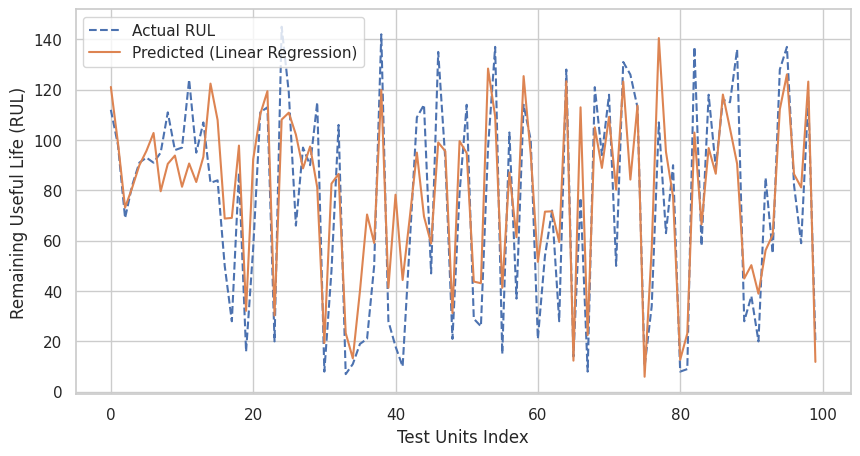

In [25]:
# Linear Regression (Baseline)

lr_model = LinearRegression()
print("Training Linear Regression (Baseline)...")
_ = evaluate_model(lr_model, X_train, y_train, X_test, y_true, "Linear Regression")

--- SVR Results ---
RMSE: 19.84
R2:   77.20%


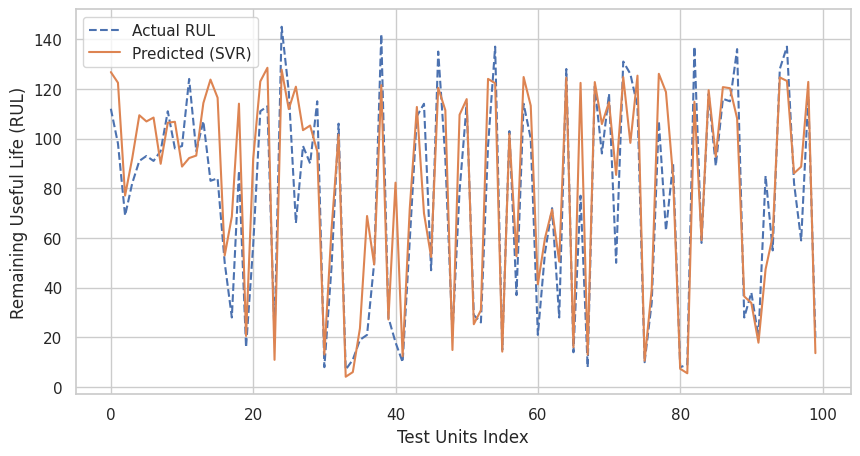

In [26]:
# Support Vector Regressor (SVR)

svr_model = SVR(kernel='rbf', C=10, epsilon=0.1)  # Kernel='rbf' for non-linear relationships

_ = evaluate_model(svr_model, X_train, y_train, X_test, y_true, "SVR")

--- Random Forest Results ---
RMSE: 18.16
R2:   80.91%


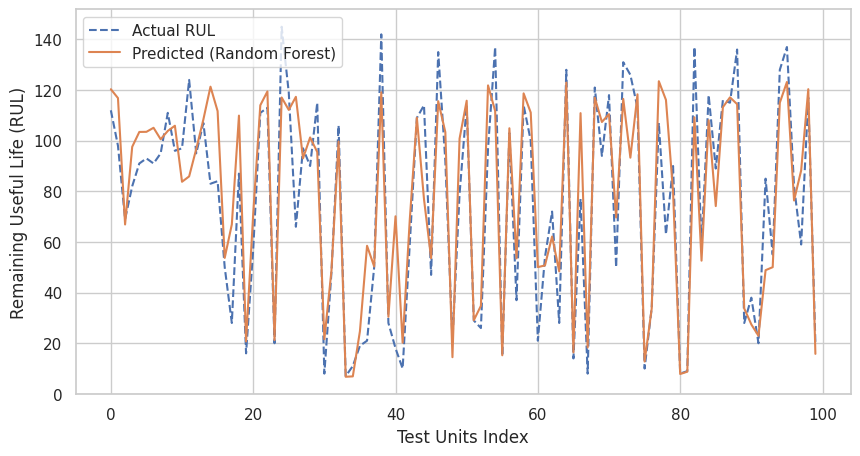

In [27]:
# Random Forest Regressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)

_ = evaluate_model(rf_model, X_train, y_train, X_test, y_true, "Random Forest")

--- XGBoost Results ---
RMSE: 17.69
R2:   81.87%


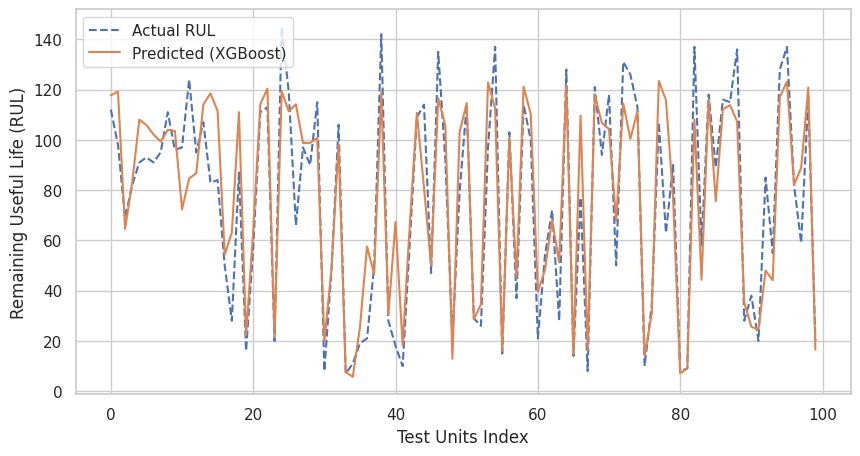

In [28]:
# XGBoost Regressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, n_jobs=-1, random_state=42)

_ = evaluate_model(xgb_model, X_train, y_train, X_test, y_true, "XGBoost")

### Final Model Selection & Deployment

After running the experiments, we aggregate the results to pick the winner.
* **Selection Criteria:** The model with the **lowest RMSE**.
* **Deployment:** Once the best model is identified, we save it (serialize it) using `joblib`. This allows the model to be loaded later in a Web App or API without retraining.


 FINAL MODEL COMPARISON 


,Model,RMSE,R2 Score
3,XGBoost,17.692938,0.818724
2,Random Forest,18.158424,0.809060
1,SVR,19.844600,0.771953
0,Linear Regression,21.904171,0.722160


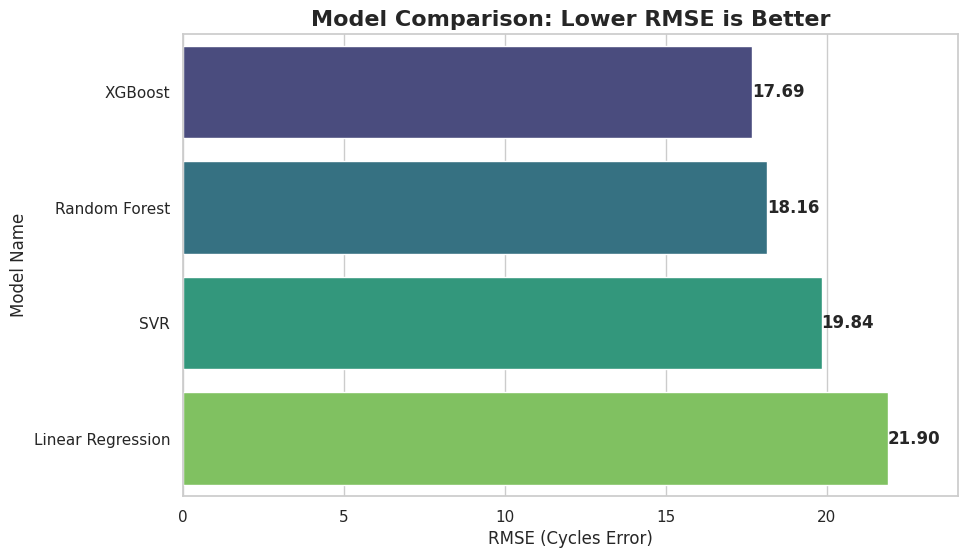

The Best Model is: XGBoost


In [29]:
# Compare Models

results_df = pd.DataFrame(results_summary).sort_values(by='RMSE')

print("\n FINAL MODEL COMPARISON ")
display(results_df.style.background_gradient(cmap='Greens_r', subset=['RMSE']))

# plot Leaderboard
plt.figure(figsize=(10, 6))
sns.barplot(x='RMSE', y='Model', data=results_df, palette='viridis')
plt.title('Model Comparison: Lower RMSE is Better', fontsize=16, fontweight='bold')
plt.xlabel('RMSE (Cycles Error)', fontsize=12)
plt.ylabel('Model Name', fontsize=12)
# Add value labels
for index, value in enumerate(results_df['RMSE']):
    plt.text(value, index, f'{value:.2f}', va='center', fontsize=12, fontweight='bold')

plt.xlim(0, max(results_df['RMSE'])*1.1)
plt.show()

print(f"The Best Model is: {results_df.iloc[0]['Model']}")

In [30]:
# Save Artifacts for Production

best_model = xgb_model
joblib.dump(best_model, 'best_rul_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler saved successfully!")
print("Files created: 'best_rul_model.pkl', 'scaler.pkl'")
print("Ready for deployment in Web App or API.")

Model and Scaler saved successfully!
Files created: 'best_rul_model.pkl', 'scaler.pkl'
Ready for deployment in Web App or API.


In [31]:
# Save Artifacts for Production

best_model = xgb_model
joblib.dump(best_model, 'best_rul_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler saved successfully!")
print("Files created: 'best_rul_model.pkl', 'scaler.pkl'")
print("Ready for deployment in Web App or API.")

Model and Scaler saved successfully!
Files created: 'best_rul_model.pkl', 'scaler.pkl'
Ready for deployment in Web App or API.


### Real-time Simulation (The "Digital Twin")

Metrics like RMSE are abstract. To truly trust the model, we need to see it in action.
In this final step, we perform a **Trajectory Reconstruction**:
1.  Select a random engine from the Test Set (e.g., Unit #24).
2.  Feed its sensor data cycle-by-cycle into the model.
3.  Compare the **Predicted RUL** vs. the **Actual RUL** over time.

This visualization proves that the model isn't just guessing; it's tracking the degradation trend as it happens.

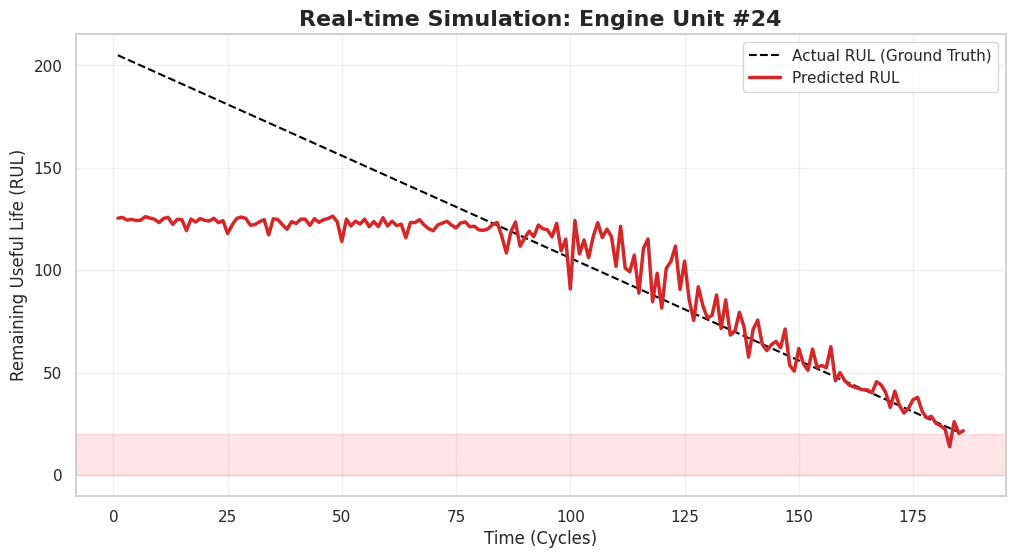

In [32]:
def simulate_engine_life(unit_id, model, scaler, data_test, true_rul_df):
    """
    Simulates the RUL prediction for a single engine unit over its entire history.
    Visualizes the 'Actual' vs 'Predicted' degradation path.
    """
    # Take the data for the specific unit
    # Note: data_test is ALREADY scaled
    engine_data = data_test[data_test['unit_number'] == unit_id].copy()
    # Extract features directly
    X_engine = engine_data[features_to_normalize]
    pred_rul = model.predict(X_engine) # Predict
    #Construct Ground Truth (Actual RUL) for visualization
    # We know the Final RUL from the file, so we back-calculate the path.
    final_true_rul = true_rul_df.iloc[unit_id - 1]['RUL']
    max_cycle = engine_data['time_cycles'].max()
    true_rul_series = []
    current_rul = final_true_rul + max_cycle
    for _ in range(len(engine_data)):
        current_rul -= 1
        true_rul_series.append(current_rul)

    plt.figure(figsize=(12, 6))
    plt.plot(engine_data['time_cycles'], true_rul_series, color='black', linestyle='--', label='Actual RUL (Ground Truth)')
    plt.plot(engine_data['time_cycles'], pred_rul, color='#d62728', linewidth=2.5, label='Predicted RUL')
    plt.title(f'Real-time Simulation: Engine Unit #{unit_id}', fontsize=16, fontweight='bold')
    plt.xlabel('Time (Cycles)', fontsize=12)
    plt.ylabel('Remaining Useful Life (RUL)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axhspan(0, 20, color='red', alpha=0.1, label='Failure Zone')
    plt.show()


# Simulate Engine Unit #24
simulate_engine_life(24, best_model, scaler, fd001_test, rul)

### conclusion

"In future iterations, I plan to implement LSTM (Long Short-Term Memory) networks to better capture the temporal dependencies in the time-series data, and apply Hyperparameter Tuning using Optuna to squeeze more performance out of XGBoost."